In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [14]:
def load_data(file_path):
    
	df = pd.read_csv(file_path, sep='\t')

	df.columns = df.columns.str.replace('[<>]', '', regex=True).str.capitalize()

	df.index = pd.to_datetime(df['Date'])
	df.index.name = 'Datetime'

	df.drop(columns=['Date'], inplace=True)

	return df

In [15]:
def calculate_envelopes(series, period=20, deviation_pct=2):
	
	ma = series.ewm(span=period, adjust=False).mean()

	deviation = deviation_pct / 100.0
	
	upper = ma * (1 + deviation)
	lower = ma * (1 - deviation)
	
	return ma, upper, lower

In [16]:
def envelope_strategy(df_initial, period, deviation_pct, fee, tp_pct, sl_pct, slippage_pct, start_date=None, end_date=None):
	df = df_initial.copy()
	
	if start_date:
		df = df.loc[start_date:]
	if end_date:
		df = df.loc[:end_date]
	
	df['MA'], df['Upper'], df['Lower'] = calculate_envelopes(df['Close'], period, deviation_pct)
	
	df['Signal'] = 0
	df.loc[df['Close'] < df['Lower'], 'Signal'] = 1
	df.loc[df['Close'] > df['Upper'], 'Signal'] = -1
	df['Signal'] = df['Signal'].shift(1, fill_value=0)
	
	df['Position'] = df['Signal'].replace(0, np.nan).ffill().fillna(0)
	
	df['Entry_Price'] = 0.0
	df['PnL'] = 0.0
	df['Equity'] = 0.0
		
	for i in range(1, len(df)):
		pnl = 0.0
		pos = df['Position'].iloc[i]
		prev_pos = df['Position'].iloc[i-1]
		entry = df['Entry_Price'].iloc[i-1]

		slippage = (df['High'].iloc[i] - df['Low'].iloc[i]) * (slippage_pct / 100)

		if pos != 0 and entry == 0:
			entry = df['Open'].iloc[i] + (slippage if pos == 1 else -slippage)
			pnl -= fee
			
		df.at[df.index[i], 'Entry_Price'] = entry

		if prev_pos != 0 and entry > 0:
			long = (prev_pos == 1)
			
			tp_level = entry * (1 + (tp_pct / 100)) if long else entry * (1 - (tp_pct / 100))
			sl_level = entry * (1 - (sl_pct / 100)) if long else entry * (1 + (sl_pct / 100))

			tp_hit = (df['High'].iloc[i] >= tp_level) if long else (df['Low'].iloc[i] <= tp_level)
			sl_hit = (df['Low'].iloc[i] <= sl_level) if long else (df['High'].iloc[i] >= sl_level)

			exit_trade = False

			if tp_hit and sl_hit:
				if (df['Close'].iloc[i] - df['Open'].iloc[i]) * (1 if long else -1) >= 0:
					pnl += abs(tp_level - entry)
				else:
					pnl -= abs(entry - sl_level)
				exit_trade = True

			elif tp_hit:
				pnl += abs(tp_level - entry)
				exit_trade = True

			elif sl_hit:
				pnl -= abs(entry - sl_level)
				exit_trade = True

			elif pos != prev_pos:
				pnl += (df['Open'].iloc[i] - entry) * (1 if long else -1)
				exit_trade = True
				
			else:
				pnl += (df['Close'].iloc[i] - df['Close'].iloc[i-1]) * (1 if long else -1)

			if exit_trade:
				pnl -= slippage
				df.at[df.index[i], 'Position'] = 0
				df.at[df.index[i], 'Entry_Price'] = 0
				pnl -= fee

				exit_price = tp_level if tp_hit else sl_level if sl_hit else df['Open'].iloc[i]
				df.at[df.index[i], 'Exit_Price'] = exit_price

		df.at[df.index[i], 'PnL'] = pnl

	df['Equity'] = df['PnL'].cumsum()

	return df

In [17]:
def plot_strategy(df):
	fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

	ax1.plot(df.index, df['Close'], label='Close', color='black', alpha=0.5)
	ax1.plot(df.index, df['Upper'], label='Envelopes', color='orange', linestyle='--')
	ax1.plot(df.index, df['Lower'], color='orange', linestyle='--')

	trade_happened = (df['Position'] != 0) & (df['Position'].shift(1, fill_value=0) == 0)
	long_entries = df[trade_happened & (df['Position'] == 1)]
	short_entries = df[trade_happened & (df['Position'] == -1)]

	ax1.scatter(long_entries.index, long_entries['Entry_Price'], marker='^', color='green', s=80, label='Buy/Long(Last signal was buy -> Close BELOW Lower Envelope)')
	ax1.scatter(short_entries.index, short_entries['Entry_Price'], marker='v', color='red', s=80, label='Sell/Short(Last signal was sell -> Close ABOVE Upper Envelope)')

	exit_trade_happened = (df['Position'] == 0) & (df['Position'].shift(1, fill_value=0) != 0)

	long_exits = df[exit_trade_happened & (df['Position'].shift(1) == 1)]
	short_exits = df[exit_trade_happened & (df['Position'].shift(1) == -1)]

	buy_tp = long_exits[long_exits['PnL'] > 0]
	buy_sl = long_exits[long_exits['PnL'] < 0]

	sell_tp = short_exits[short_exits['PnL'] > 0]
	sell_sl = short_exits[short_exits['PnL'] < 0]

	ax1.scatter(buy_tp.index, buy_tp['Exit_Price'], marker='+', color='green', s=90, label='Buy Take Profit')
	ax1.scatter(buy_sl.index, buy_sl['Exit_Price'], marker='x', color='magenta', s=90, label='Buy Stop Loss')

	ax1.scatter(sell_tp.index, sell_tp['Exit_Price'], marker='+', color='red', s=90, label='Sell Take Profit')
	ax1.scatter(sell_sl.index, sell_sl['Exit_Price'], marker='x', color='purple', s=90, label='Sell Stop Loss')

	ax1.set_title('Envelope Strategy Trades')
	ax1.set_ylabel('Close Price')
	ax1.grid(True)
	ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))

	ax2.plot(df.index, df['Equity'], label='Equity', color='purple')
	ax2.set_title('Equity over time')
	ax2.set_ylabel('Equity')
	ax2.set_xlabel('Date')
	ax2.grid(True)
	ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))

	plt.tight_layout()
	plt.show()

In [18]:
def calculate_sharpe_ratio(returns, risk_free_rate=0.0, periods_per_year=252):

	if returns.std() == 0:
		return np.nan

	sharpe_ratio = (returns.mean() - (risk_free_rate / periods_per_year)) / returns.std()
	annual_sharpe = sharpe_ratio * np.sqrt(periods_per_year)

	return annual_sharpe

In [19]:
def optimize_strategy(df, fee, slippage_pct):
	best_strategy = df
	best_sharpe = -np.inf
	best_period = 0
	best_deviation_pct = 0.0
	best_tp_pct = 0.0
	best_sl_pct = 0.0

	for period in range(10, 40, 10):
		for deviation_pct in range(1, 6, 1):
			for tp_pct in range (1, 6, 1):
				for sl_pct in range (1, 6, 1):
						strategy = envelope_strategy(df, period, deviation_pct, fee, tp_pct, sl_pct, slippage_pct)
						sharpe = calculate_sharpe_ratio(strategy['PnL'])

						if sharpe > best_sharpe:
							best_strategy = strategy
							best_sharpe = sharpe
							best_period = period
							best_deviation_pct = deviation_pct
							best_tp_pct = tp_pct
							best_sl_pct = sl_pct

	return best_strategy, best_sharpe, best_period, best_deviation_pct, best_tp_pct, best_sl_pct

In [31]:
aapl = load_data(r'data/AAPL_Daily_201510300000_202510290000.csv')
aapl.head()

,Open,High,Low,Close,Tickvol,Vol,Spread
Datetime,,,,,,,
2015-10-30,30.21,30.25,29.77,29.81,138173,125878968,0
2015-11-02,29.97,30.34,29.90,30.30,130332,112694928,0
2015-11-03,30.20,30.87,30.18,30.65,166227,155777440,0
2015-11-04,30.78,30.96,30.41,30.50,162406,150921656,0
2015-11-05,30.46,30.68,30.05,30.23,150077,135198824,0


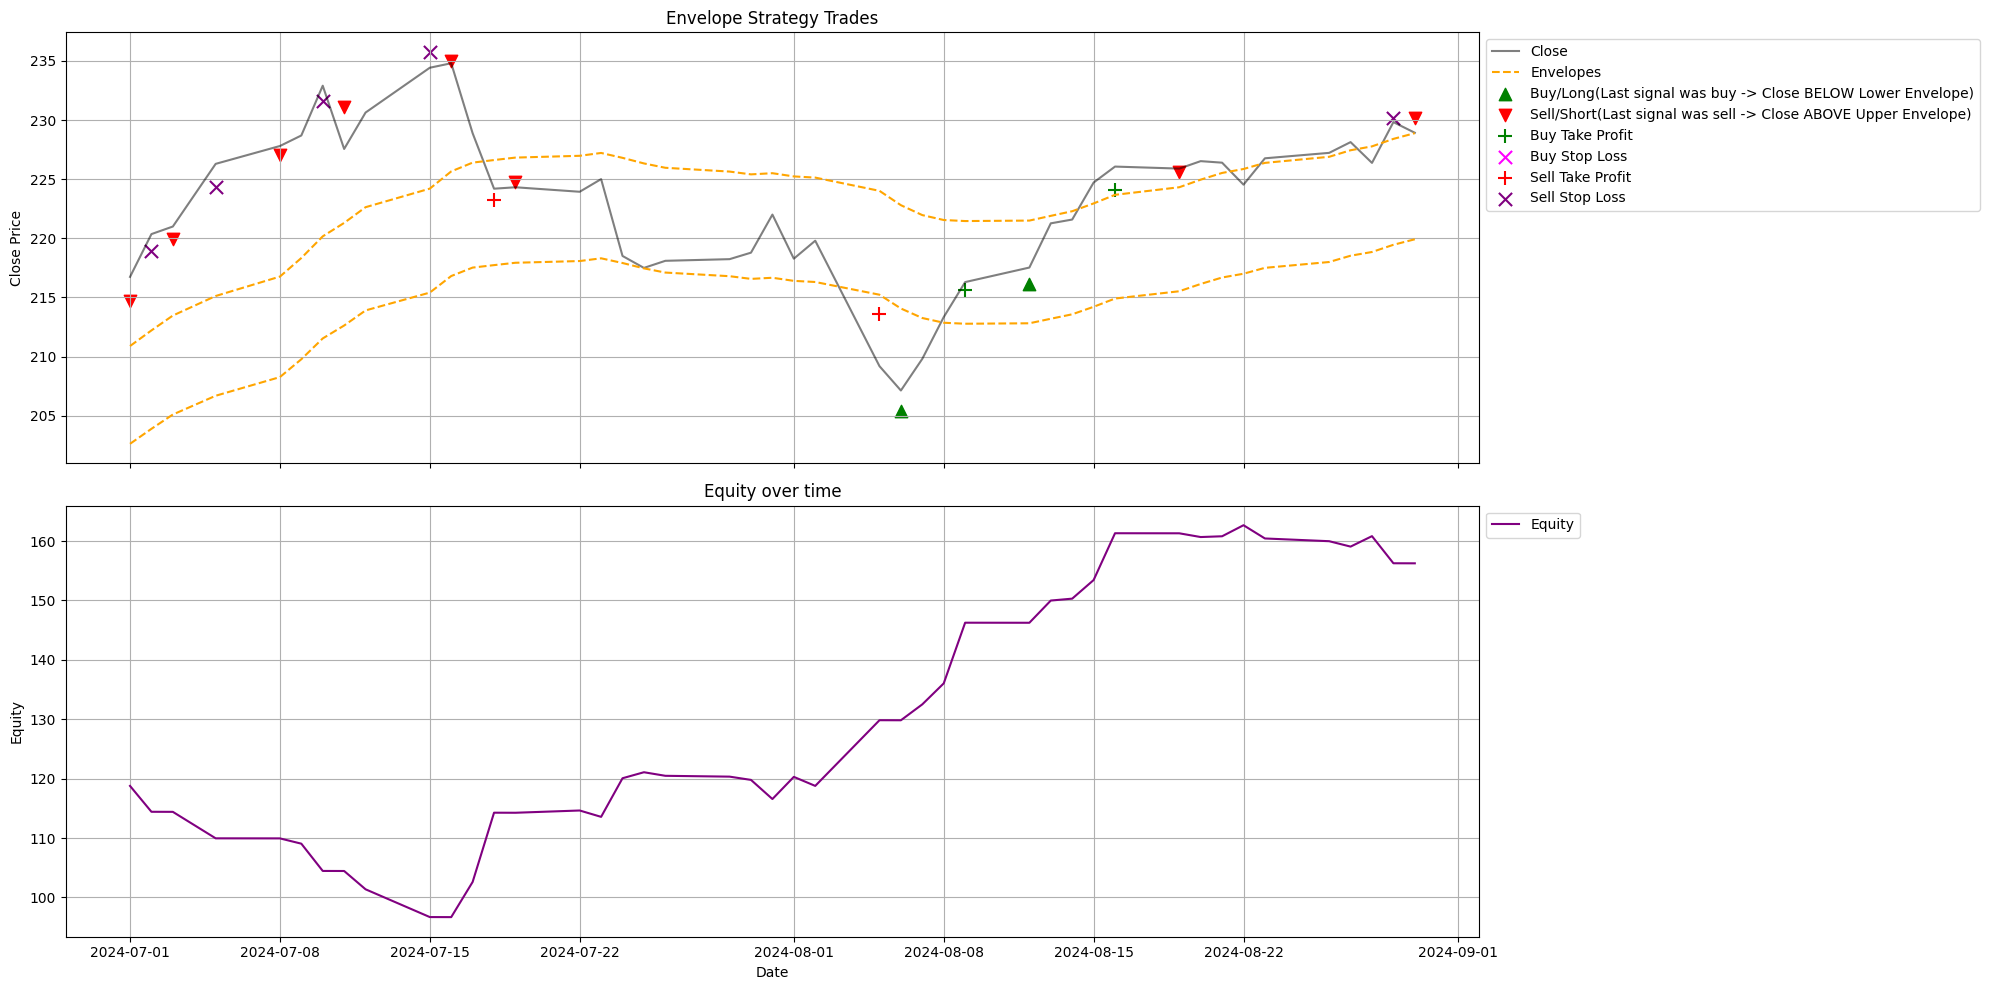

In [21]:
df = aapl
period = 20
deviation_pct = 2
fee = 0.01
tp_pct = 5
sl_pct = 2
slippage_pct = 1

strategy = envelope_strategy(df, period, deviation_pct, fee, tp_pct, sl_pct, slippage_pct)
subset = strategy.loc['2024-06-30':'2024-09-01']
plot_strategy(subset)

Sharpe ratio: 0.901852519701297


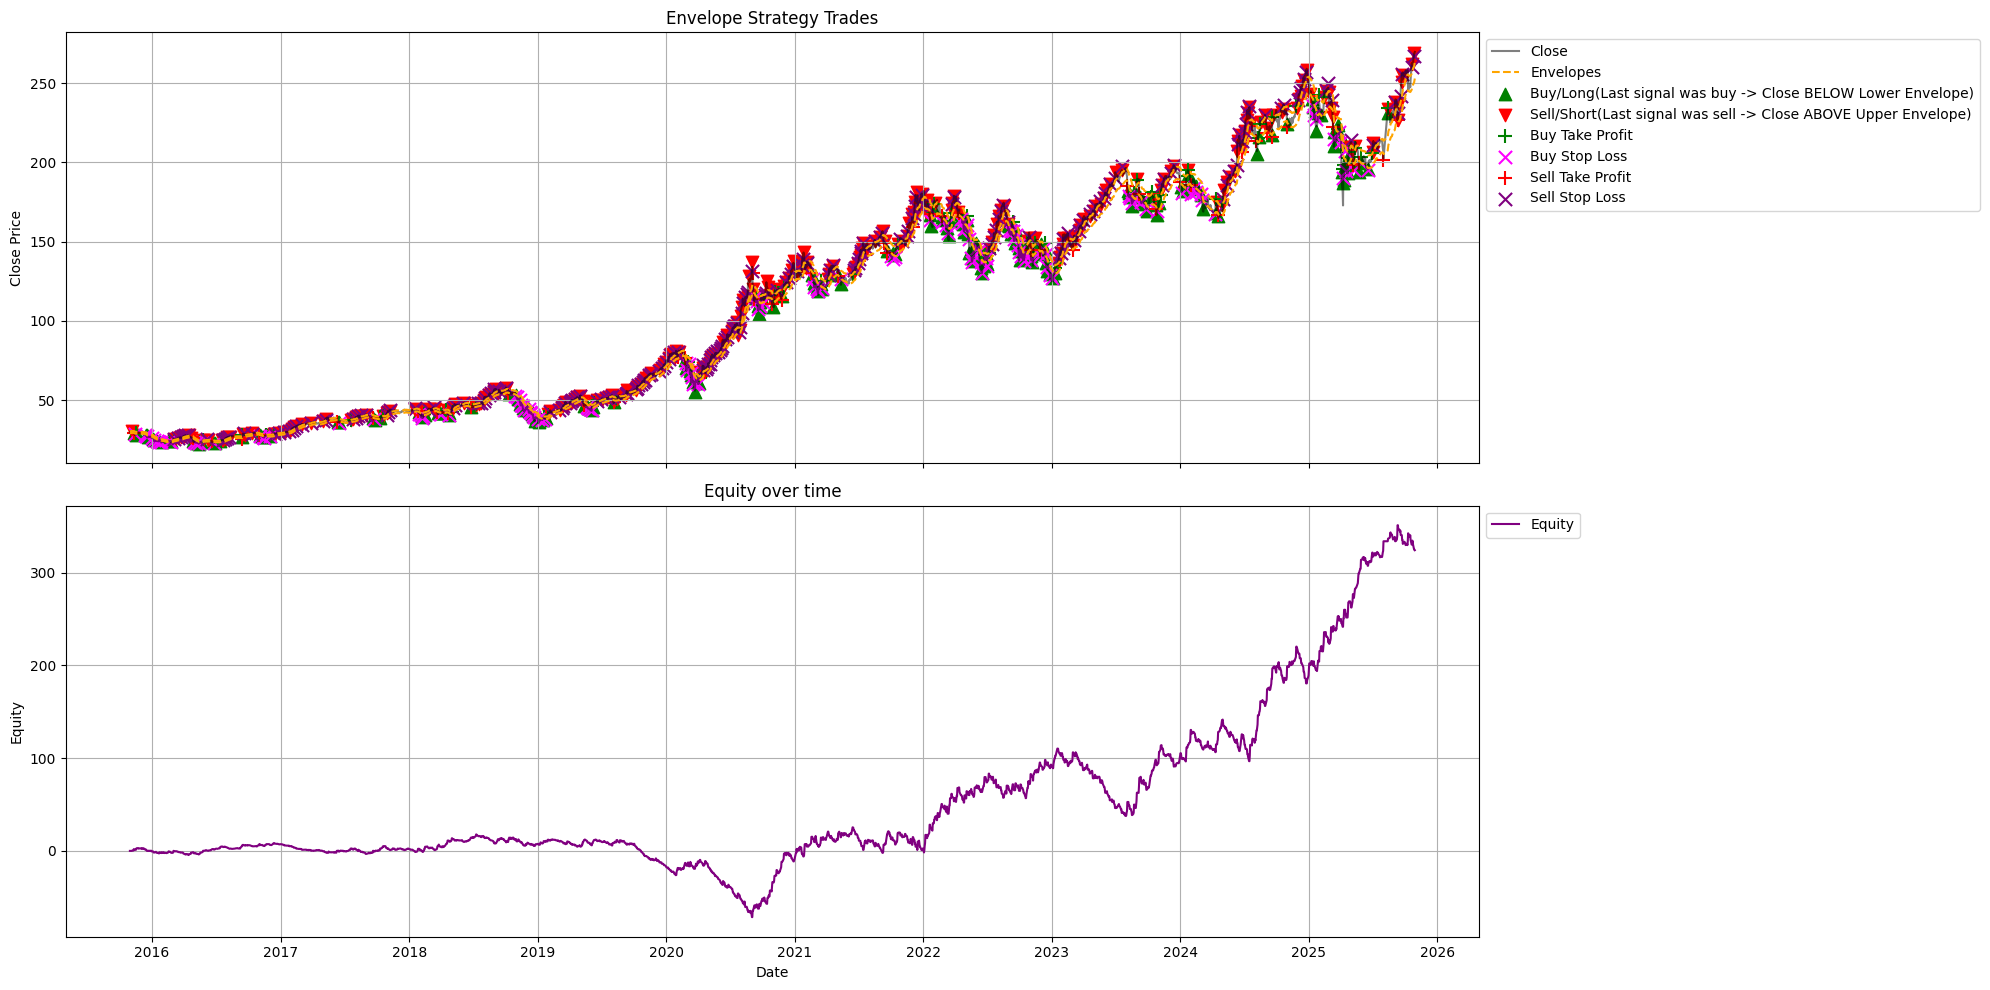

In [22]:
df = aapl
period = 20
deviation_pct = 2
fee = 0.01
tp_pct = 5
sl_pct = 2
slippage_pct = 1

strategy = envelope_strategy(df, period, deviation_pct, fee, tp_pct, sl_pct, slippage_pct)

sharpe = calculate_sharpe_ratio(strategy['PnL'])
print(f'Sharpe ratio: {sharpe}')

plot_strategy(strategy)

Best Sharpe Ratio: 1.9571926501568053
Best Period: 20
Best Deviation %: 5
Best Take Profit %: 5
Best Stop Loss %: 1


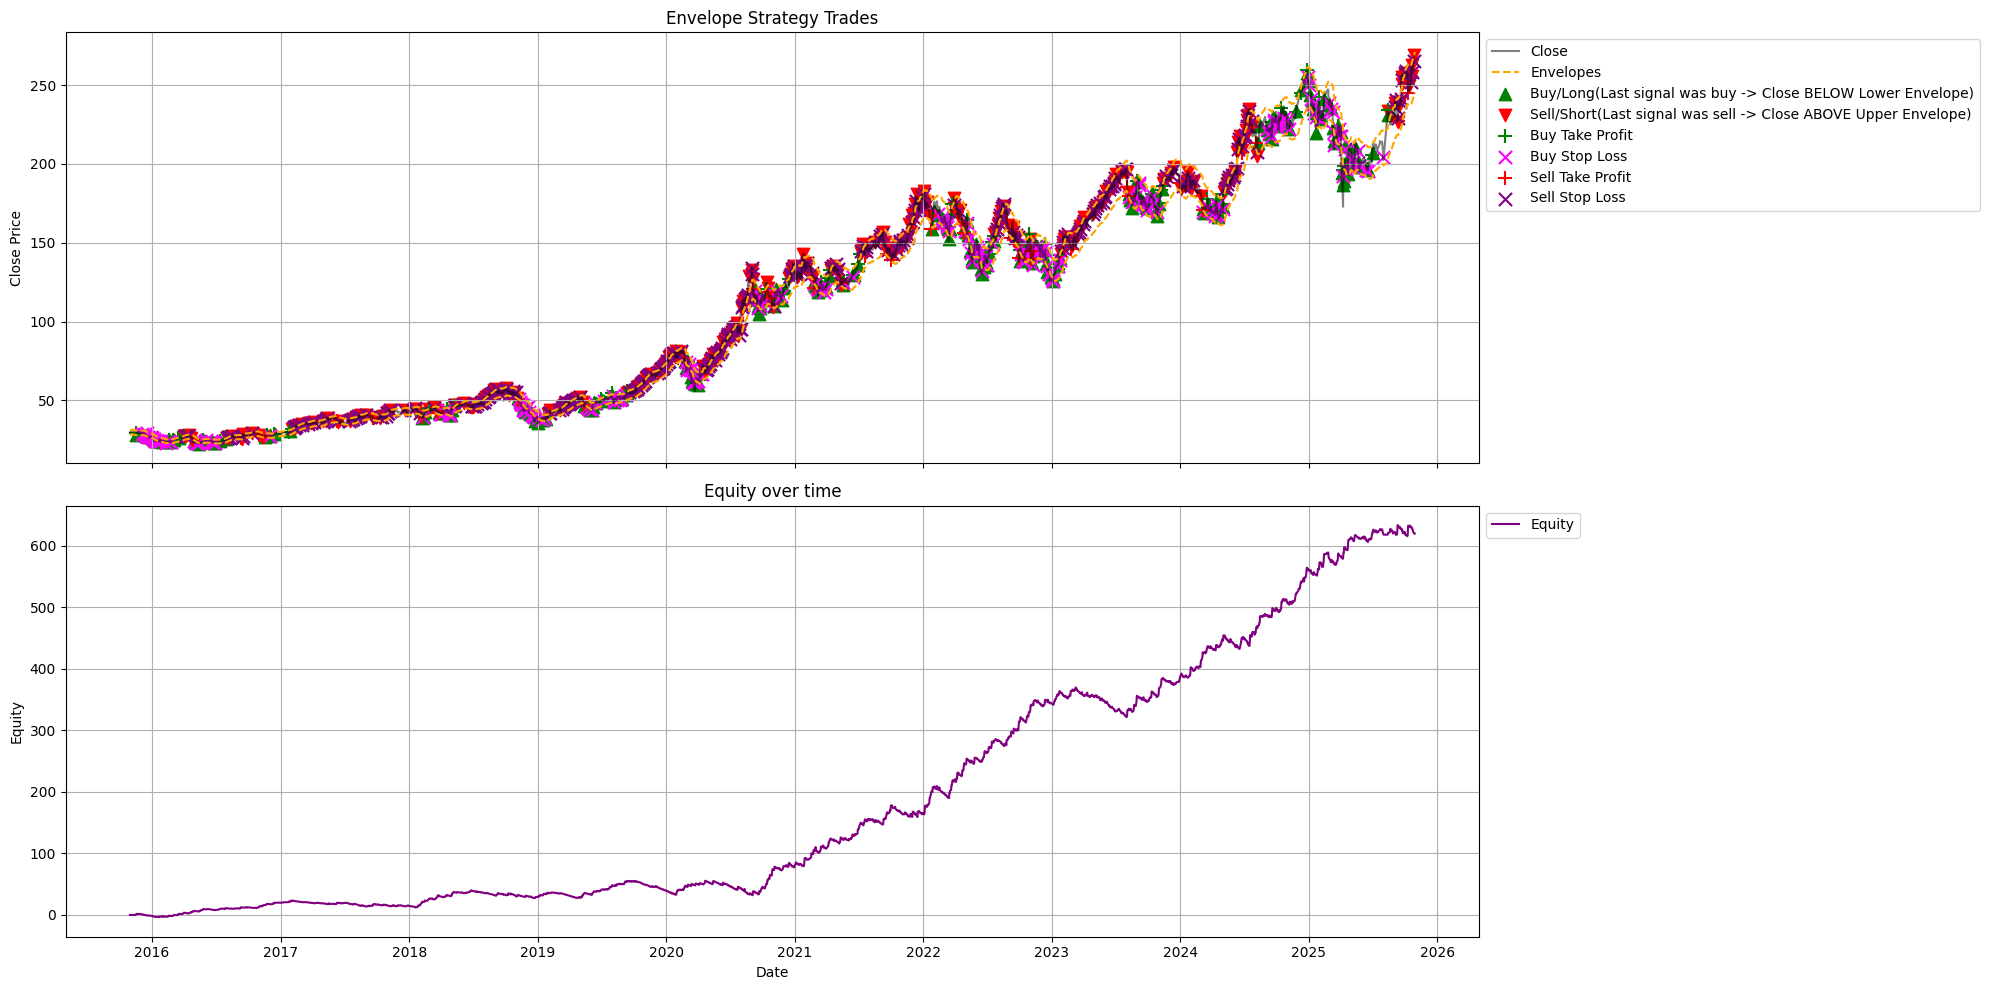

In [ ]:
fee = 0.01
slippage_pct = 1

best_strategy, best_sharpe, best_period, best_deviation_pct, best_tp_pct, best_sl_pct = optimize_strategy(aapl, fee, slippage_pct)

print(f"Best Sharpe Ratio: {best_sharpe}")
print(f"Best Period: {best_period}")
print(f"Best Deviation %: {best_deviation_pct}")
print(f"Best Take Profit %: {best_tp_pct}")
print(f"Best Stop Loss %: {best_sl_pct}")

plot_strategy(best_strategy)